In [1]:
from classes.stock_client import StockClient
from classes.quant_analytics import QuantAnalytics as qa

In [2]:
client = StockClient(ttl_price=60, ttl_info=900)

In [3]:
quant = qa(client)

In [4]:
symbols = ["AAPL", "MSFT", "GOOGL", "NVDA"]

In [5]:
prices  = quant.prices_df(symbols, period="1y")
prices

,AAPL,MSFT,GOOGL,NVDA
date,,,,
2025-04-24,207.465775,384.357483,158.729599,106.404922
2025-04-25,208.371826,388.872955,161.400360,110.983856
2025-04-28,209.228104,388.188171,160.055008,108.704391
2025-04-29,210.293457,391.046295,159.606583,108.994316
2025-04-30,211.577850,392.257080,158.251266,108.894333
...,...,...,...,...
2026-04-17,270.230011,422.790009,341.679993,201.679993
2026-04-20,273.049988,418.070007,337.420013,202.059998
2026-04-21,266.170013,424.160004,332.290009,199.880005


In [6]:
returns = quant.returns_df(symbols, period="1y")
returns

,AAPL,MSFT,GOOGL,NVDA
date,,,,
2025-04-25,0.004358,0.011680,0.016686,0.042133
2025-04-28,0.004101,-0.001762,-0.008370,-0.020753
2025-04-29,0.005079,0.007336,-0.002806,0.002664
2025-04-30,0.006089,0.003091,-0.008528,-0.000918
2025-05-01,0.003852,0.073486,0.015620,0.024397
...,...,...,...,...
2026-04-17,0.025600,0.006002,0.016704,0.016649
2026-04-20,0.010381,-0.011227,-0.012546,0.001882
2026-04-21,-0.025520,0.014462,-0.015320,-0.010847


In [7]:
cum_ret = quant.cumulative_returns_df(symbols)
cum_ret

,AAPL,MSFT,GOOGL,NVDA
date,,,,
2025-04-24,100.000000,100.000000,100.000000,100.000000
2025-04-25,100.436723,101.174811,101.682585,104.303310
2025-04-28,100.849455,100.996647,100.835011,102.161055
2025-04-29,101.362963,101.740258,100.552502,102.433528
2025-04-30,101.982050,102.055273,99.698649,102.339563
...,...,...,...,...
2026-04-17,130.252815,109.999162,215.259154,189.540096
2026-04-20,131.612064,108.771138,212.575358,189.897227
2026-04-21,128.295867,110.355599,209.343444,187.848457


In [8]:
quant.beta('AAPL',benchmark='SPY',period='1y',interval='1d')


1.0130519443442845

In [9]:
quant.beta_bulk(symbols,benchmark='SPY',period='1y')

{'AAPL': 1.0130519443442845,
 'MSFT': 0.9516589839478243,
 'GOOGL': 1.1900008299832465,
 'NVDA': 1.7741114553555912}

In [10]:
quant.returns_bulk(symbols,period='1y')

,AAPL,MSFT,GOOGL,NVDA
date,,,,
2025-04-25,0.004358,0.011680,0.016686,0.042133
2025-04-28,0.004101,-0.001762,-0.008370,-0.020753
2025-04-29,0.005079,0.007336,-0.002806,0.002664
2025-04-30,0.006089,0.003091,-0.008528,-0.000918
2025-05-01,0.003852,0.073486,0.015620,0.024397
...,...,...,...,...
2026-04-17,0.025600,0.006002,0.016704,0.016649
2026-04-20,0.010381,-0.011227,-0.012546,0.001882
2026-04-21,-0.025520,0.014462,-0.015320,-0.010847


In [11]:
quant.calmar_ratio('NVDA',period='2y')

1.593566078906989

In [12]:
quant.correlation_matrix(symbols,period='1y',interval='1d')

,AAPL,MSFT,GOOGL,NVDA
AAPL,1.000000,0.133357,0.326655,0.274111
MSFT,0.133357,1.000000,0.180934,0.392468
GOOGL,0.326655,0.180934,1.000000,0.313336
NVDA,0.274111,0.392468,0.313336,1.000000


In [13]:
quant.cvar('AAPL',period='2y',confidence=0.05)

0.0010680948364006392

In [14]:
quant.drawdown_df(symbols,period='1y')

,AAPL,MSFT,GOOGL,NVDA
date,,,,
2025-04-23,0.000000,NaN,NaN,0.000000
2025-04-24,0.000000,0.000000,0.000000,0.000000
2025-04-25,0.000000,0.000000,0.000000,0.000000
2025-04-28,0.000000,-0.001761,-0.008335,-0.020539
2025-04-29,0.000000,0.000000,-0.011114,-0.017926
...,...,...,...,...
2026-04-17,-0.054884,-0.216802,-0.005149,-0.025782
2026-04-20,-0.045021,-0.225546,-0.017552,-0.023946
2026-04-21,-0.069083,-0.214264,-0.032489,-0.034477


In [15]:
quant.metrics_df(symbols,'SPY',period='1y', risk_free_rate=0.05)

,AAPL,MSFT,GOOGL,NVDA
annualised_volatility,0.233360,0.246019,0.282580,0.333990
max_drawdown,-0.137985,-0.339101,-0.203665,-0.202144
sharpe_ratio,1.164666,0.241958,2.656587,2.011456
sortino_ratio,1.829395,0.300643,4.634296,3.293363
beta,1.013052,0.951659,1.190001,1.774111
calmar_ratio,0.566786,0.436423,1.609244,2.583768
var_95_1d,0.021379,0.023445,0.023142,0.033032
cvar_95_1d,0.030812,0.035383,0.031772,0.040536


In [16]:
quant.rolling_sharpe_df(symbols,period='1y',window=63,risk_free_rate=0.05)

,AAPL,MSFT,GOOGL,NVDA
date,,,,
2025-07-24,0.673054,6.052489,2.964071,6.736417
2025-07-25,0.371355,5.736319,2.716080,6.347258
2025-07-28,0.309589,5.445928,2.443342,6.182230
2025-07-29,0.012909,5.491163,2.792323,6.446300
2025-07-30,-0.255201,5.365471,2.891430,6.675188
...,...,...,...,...
2026-04-17,0.646735,-0.825475,0.344291,0.855885
2026-04-20,0.965072,-1.033321,0.285964,0.923348
2026-04-21,1.127449,-0.731566,0.416236,1.313800


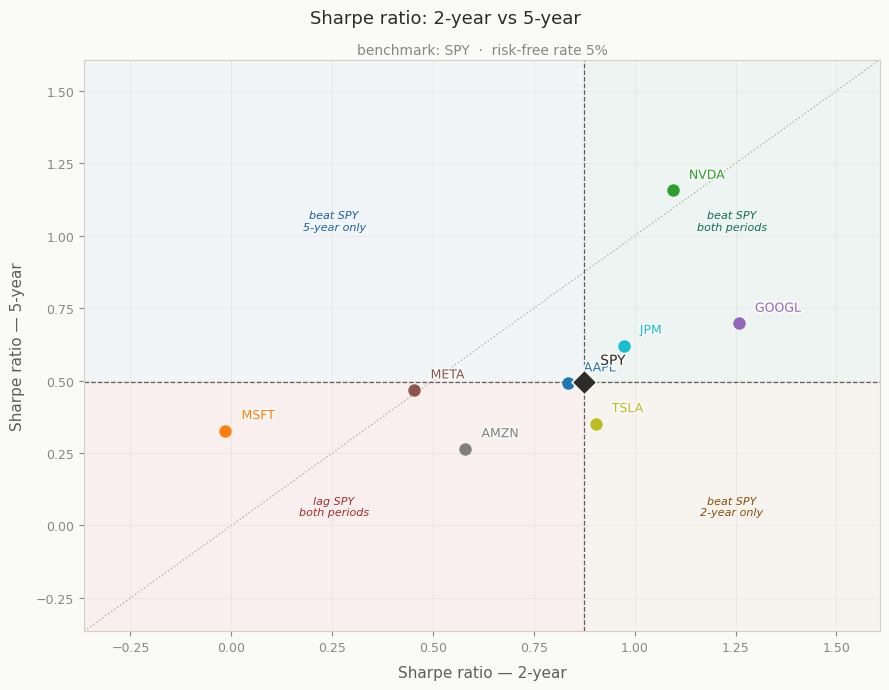

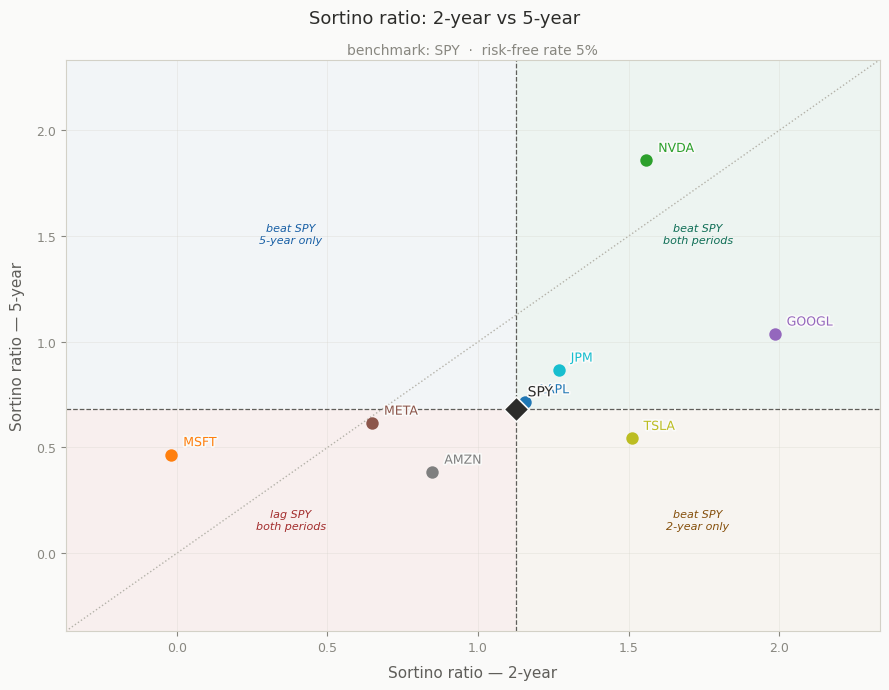

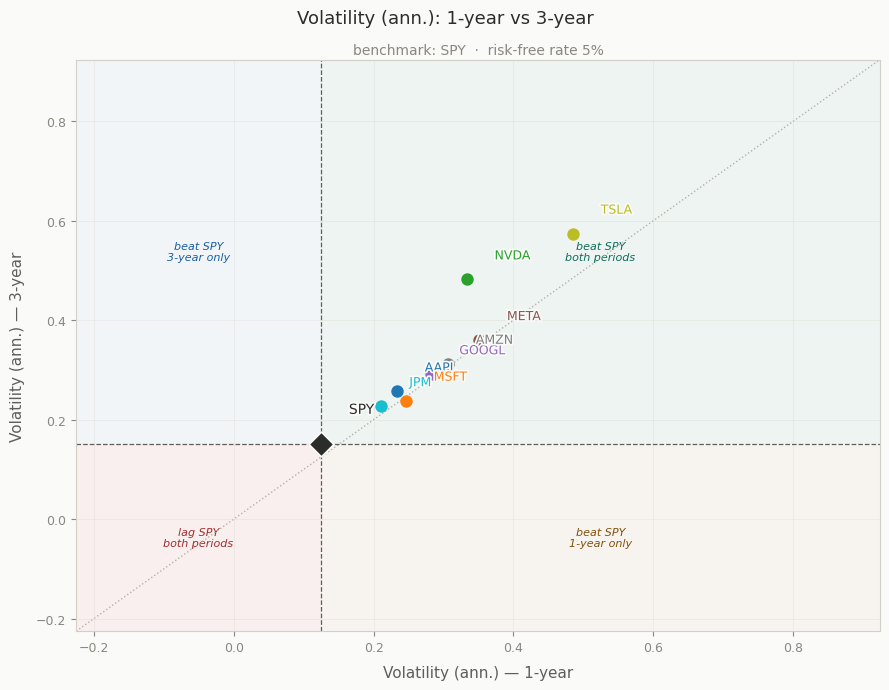

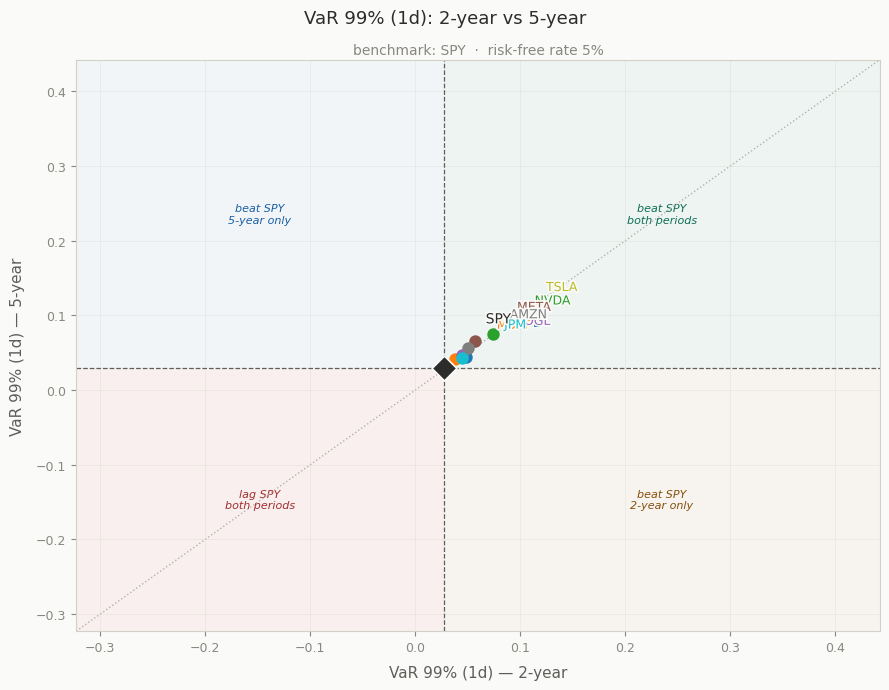

In [17]:
"""
Generic risk-metric scatter plot — period and metric are both configurable.
"""

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from typing import Callable

from classes.stock_client import StockClient
from classes.quant_analytics import QuantAnalytics


# ---------------------------------------------------------------------------
# Built-in metric registry
# ---------------------------------------------------------------------------

# Each entry: (callable(quant, sym, period, rf) -> float, display_label)
_METRICS: dict[str, tuple[Callable, str]] = {
    "sharpe":     (lambda q, s, p, rf: q.sharpe_ratio(s, p, rf),      "Sharpe ratio"),
    "sortino":    (lambda q, s, p, rf: q.sortino_ratio(s, p, rf),     "Sortino ratio"),
    "calmar":     (lambda q, s, p, rf: q.calmar_ratio(s, p),          "Calmar ratio"),
    "volatility": (lambda q, s, p, rf: q.historical_volatility(s, p), "Volatility (ann.)"),
    "max_drawdown":(lambda q, s, p, rf: q.max_drawdown(s, p),         "Max drawdown"),
    "var":        (lambda q, s, p, rf: q.var(s, p),                   "VaR 95% (1d)"),
    "cvar":       (lambda q, s, p, rf: q.cvar(s, p),                  "CVaR 95% (1d)"),
    "beta":       (lambda q, s, p, rf: q.beta(s, period=p),           "Beta (vs SPY)"),
}


def list_metrics() -> list[str]:
    """Return available built-in metric names."""
    return list(_METRICS.keys())


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def _period_label(period: str) -> str:
    labels = {
        "1y": "1-year", "2y": "2-year", "3y": "3-year",
        "5y": "5-year", "10y": "10-year", "ytd": "YTD", "max": "max",
    }
    return labels.get(period, period)


def _resolve_metric(
    metric: str | Callable,
    metric_label: str | None,
) -> tuple[Callable, str]:
    """Return (fn, label) from a string key or a raw callable."""
    if callable(metric):
        if metric_label is None:
            raise ValueError(
                "Pass metric_label='...' when supplying a custom callable."
            )
        return metric, metric_label

    if isinstance(metric, str):
        if metric not in _METRICS:
            raise ValueError(
                f"Unknown metric '{metric}'. "
                f"Available: {list(_METRICS.keys())}"
            )
        fn, default_label = _METRICS[metric]
        return fn, metric_label or default_label

    raise TypeError("metric must be a string key or a callable.")


# ---------------------------------------------------------------------------
# Main plot function
# ---------------------------------------------------------------------------

def plot_scatter(
    symbols: list[str],
    metric: str | Callable = "sharpe",
    period_x: str = "2y",
    period_y: str = "5y",
    benchmark: str = "SPY",
    risk_free_rate: float = 0.05,
    metric_label: str | None = None,
    figsize: tuple = (9, 7),
) -> plt.Figure:
    """
    Scatter plot comparing any risk metric across two time periods.

    Parameters
    ----------
    symbols      : list of ticker strings
    metric       : built-in name OR a callable(quant, symbol, period, rf) -> float

                   Built-ins: "sharpe", "sortino", "calmar", "volatility",
                               "max_drawdown", "var", "cvar", "beta"

                   Custom example:
                       plot_scatter(syms, metric=lambda q,s,p,rf: q.var(s,p,0.99),
                                    metric_label="VaR 99%")

    period_x     : yfinance period for the x-axis  (default "2y")
    period_y     : yfinance period for the y-axis  (default "5y")
    benchmark    : reference ticker drawn as a diamond with cross-hair lines
    risk_free_rate: annual risk-free rate passed to metrics that need it
    metric_label : axis/title label; auto-set for built-ins, required for callables
    """
    fn, label = _resolve_metric(metric, metric_label)

    client = StockClient()
    quant  = QuantAnalytics(client)

    label_x = _period_label(period_x)
    label_y = _period_label(period_y)

    # --- fetch benchmark --------------------------------------------------
    try:
        bx = fn(quant, benchmark, period_x, risk_free_rate)
        by = fn(quant, benchmark, period_y, risk_free_rate)
    except Exception as e:
        raise ValueError(f"Could not fetch benchmark '{benchmark}': {e}")

    # --- fetch symbols ----------------------------------------------------
    data = {}
    for sym in symbols:
        if sym.upper() == benchmark.upper():
            continue
        try:
            data[sym] = {
                "sx": fn(quant, sym, period_x, risk_free_rate),
                "sy": fn(quant, sym, period_y, risk_free_rate),
            }
        except Exception as e:
            print(f"Skipping {sym}: {e}")

    if not data:
        raise ValueError("No data could be fetched.")

    sx_vals = [v["sx"] for v in data.values()] + [bx]
    sy_vals = [v["sy"] for v in data.values()] + [by]

    # --- plot setup -------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("#FAFAF9")
    ax.set_facecolor("#FAFAF9")

    pad = 0.35
    lo  = min(min(sx_vals), min(sy_vals)) - pad
    hi  = max(max(sx_vals), max(sy_vals)) + pad

    # --- quadrant shading -------------------------------------------------
    quad_kw = dict(zorder=0, lw=0)
    ax.fill_between([bx, hi], by, hi,  alpha=0.06, color="#1D9E75", **quad_kw)
    ax.fill_between([lo, bx], by, hi,  alpha=0.04, color="#378ADD", **quad_kw)
    ax.fill_between([bx, hi], lo, by,  alpha=0.04, color="#BA7517", **quad_kw)
    ax.fill_between([lo, bx], lo, by,  alpha=0.06, color="#E24B4A", **quad_kw)

    mid_rx = (bx + hi) / 2
    mid_lx = (lo + bx) / 2
    mid_ty = (by + hi) / 2
    mid_by = (lo + by) / 2
    quad_txt_kw = dict(fontsize=8, style="italic", ha="center", va="center", zorder=1)
    ax.text(mid_rx, mid_ty, f"beat {benchmark}\nboth periods",    color="#0F6E56", **quad_txt_kw)
    ax.text(mid_lx, mid_ty, f"beat {benchmark}\n{label_y} only", color="#185FA5", **quad_txt_kw)
    ax.text(mid_rx, mid_by, f"beat {benchmark}\n{label_x} only", color="#854F0B", **quad_txt_kw)
    ax.text(mid_lx, mid_by, f"lag {benchmark}\nboth periods",    color="#A32D2D", **quad_txt_kw)

    # --- benchmark cross-hair ---------------------------------------------
    ax.axhline(by, color="#5F5E5A", lw=0.9, ls="--", zorder=2)
    ax.axvline(bx, color="#5F5E5A", lw=0.9, ls="--", zorder=2)

    # diagonal reference
    diag = np.linspace(lo, hi, 100)
    ax.plot(diag, diag, color="#B4B2A9", lw=1.0, ls=":", zorder=1)

    # --- scatter: symbols -------------------------------------------------
    colors = plt.cm.tab10(np.linspace(0, 1, len(data)))

    for (sym, vals), color in zip(data.items(), colors):
        ax.scatter(vals["sx"], vals["sy"], color=color, s=80, zorder=4, linewidths=0)
        txt = ax.text(
            vals["sx"] + 0.04, vals["sy"] + 0.04, sym,
            fontsize=9, color=color, fontweight="500", zorder=5,
        )
        txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground="#FAFAF9")])

    # --- scatter: benchmark -----------------------------------------------
    ax.scatter(bx, by, marker="D", s=160, color="#2C2C2A", zorder=6,
               linewidths=1.2, edgecolors="#FAFAF9")
    txt = ax.text(
        bx + 0.04, by + 0.06, benchmark,
        fontsize=10, color="#2C2C2A", fontweight="500", zorder=7,
    )
    txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground="#FAFAF9")])

    # --- axes & labels ----------------------------------------------------
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(f"{label} — {label_x}", fontsize=11, color="#5F5E5A", labelpad=8)
    ax.set_ylabel(f"{label} — {label_y}", fontsize=11, color="#5F5E5A", labelpad=8)
    ax.tick_params(colors="#888780", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#D3D1C7")
    ax.grid(True, color="#D3D1C7", lw=0.4, zorder=0)

    fig.suptitle(
        f"{label}: {label_x} vs {label_y}",
        fontsize=13, fontweight="500", color="#2C2C2A", y=0.98,
    )
    ax.set_title(
        f"benchmark: {benchmark}  ·  risk-free rate {risk_free_rate:.0%}",
        fontsize=10, color="#888780", pad=4,
    )

    plt.tight_layout()
    return fig


if __name__ == "__main__":
    symbols = ["AAPL", "MSFT", "NVDA", "GOOGL", "META", "AMZN", "TSLA", "JPM"]

    # built-in string
    plot_scatter(symbols, metric="sharpe", period_x="2y", period_y="5y").savefig("plots/sharpe.png", dpi=150, bbox_inches="tight")
    plot_scatter(symbols, metric="sortino", period_x="2y", period_y="5y").savefig("plots/sortino.png", dpi=150, bbox_inches="tight")
    plot_scatter(symbols, metric="volatility", period_x="1y", period_y="3y").savefig("plots/vol.png", dpi=150, bbox_inches="tight")

    # custom callable — VaR at 99 % confidence
    plot_scatter(
        symbols,
        metric=lambda q, s, p, rf: q.var(s, p, confidence=0.99),
        metric_label="VaR 99% (1d)",
        period_x="2y",
        period_y="5y",
    ).savefig("plots/var99.png", dpi=150, bbox_inches="tight")

    plt.show()


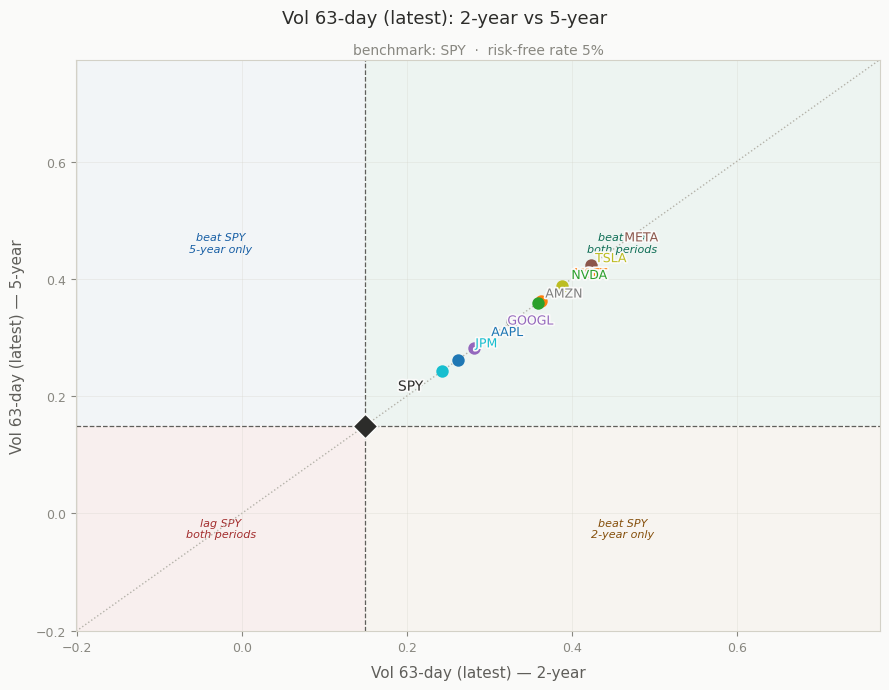

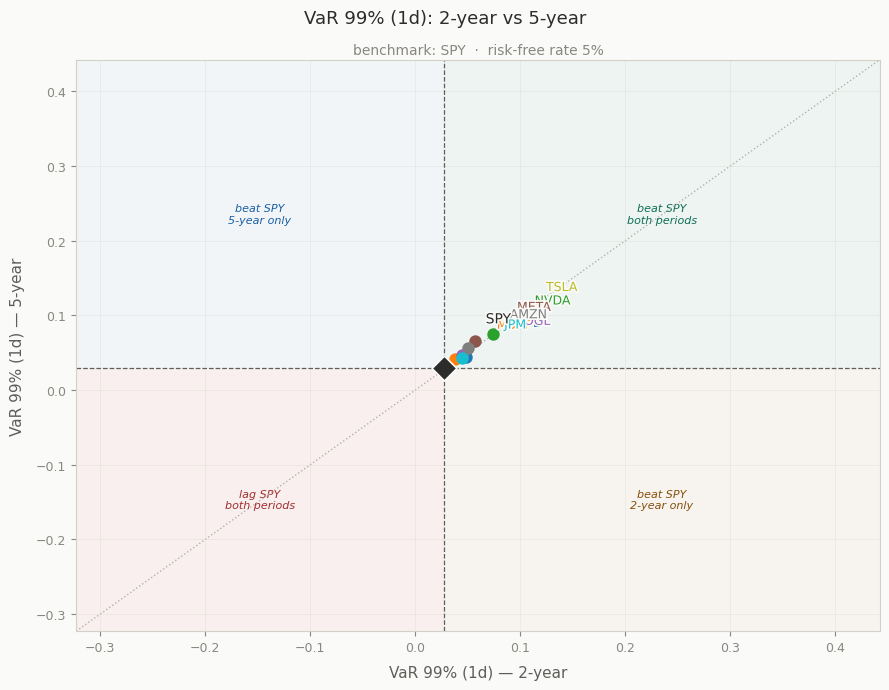

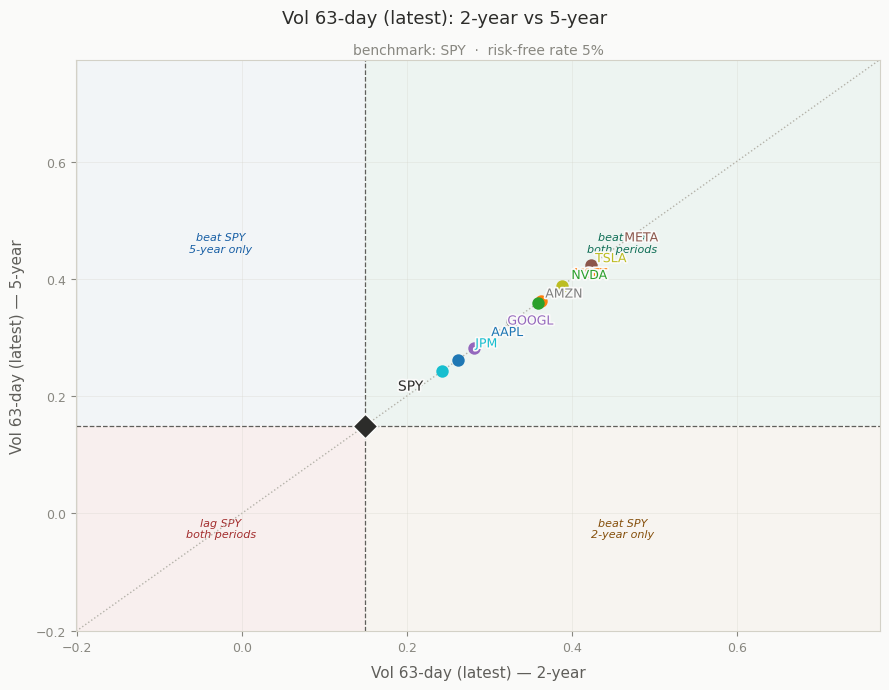

In [18]:
plot_scatter(symbols,
    metric=lambda q, s, p, rf: q.var(s, p, confidence=0.99),
    metric_label="VaR 99% (1d)")

# rolling vol at a specific window
plot_scatter(symbols,
    metric=lambda q, s, p, rf: q.rolling_volatility(s, p, window=63).iloc[-1],
    metric_label="Vol 63-day (latest)")

Seasonality

In [19]:
# raw data if you want to do your own analysis
df = quant.weekly_seasonality("AAPL", period="10y")
df

year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
week,,,,,,,,,,,
1,NaN,0.018045,0.034096,-0.051015,0.026329,-0.004824,-0.030410,-0.002386,-0.058952,-0.047850,-0.008742
2,NaN,0.009583,0.011943,0.027182,0.043372,-0.037182,0.005227,0.039655,0.026162,-0.026750,-0.042950
3,NaN,0.008065,0.007736,0.029746,0.027068,0.093833,-0.061594,0.023078,0.030336,-0.029006,-0.014805
4,NaN,0.016250,-0.038944,0.005994,-0.001318,-0.051125,0.048765,0.058461,0.004490,-0.031307,-0.029312
5,NaN,0.058467,-0.064195,0.055527,-0.027646,0.037923,0.013384,0.058727,-0.034144,0.059341,0.046122
6,NaN,0.027989,-0.021510,0.027749,0.036443,-0.010164,-0.021753,-0.021097,0.017439,-0.035466,0.071836
7,NaN,0.027248,0.102423,0.000059,0.015374,-0.040629,-0.007946,0.010198,-0.034631,0.075732,-0.079464
8,NaN,0.006926,0.017804,0.014963,-0.036621,-0.066297,-0.014644,-0.038282,0.001152,0.003884,0.034405
9,NaN,0.022831,0.004045,0.011563,-0.126785,0.001319,-0.010191,0.029446,-0.015669,-0.015109,-0.001512


In [20]:
# Check what the function actually sees internally
prices = quant._prices("AAPL", period="10y", interval="1d")
print(f"Total daily bars: {len(prices)}")
print(f"Date range: {prices.index[0]} → {prices.index[-1]}")

weekly = prices.resample("W-FRI").last().dropna()
weekly_returns = weekly.pct_change().dropna()
print(f"Weekly bars: {len(weekly_returns)}")

df = weekly_returns.to_frame(name="return")
df["week"] = df.index.isocalendar().week.astype(int)
print(f"Unique week numbers: {df['week'].nunique()}")
print(f"Week values: {sorted(df['week'].unique())}")

Total daily bars: 2514
Date range: 2016-04-25 00:00:00 → 2026-04-23 00:00:00
Weekly bars: 521
Unique week numbers: 53
Week values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53)]
